In [1]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, RANDOM_SEEDS, LEARNING_RATE, MAX_EPOCHS, WEIGHT_DECAY, XLSR_DROPOUT
from config import DANN_LAMBDA_CLASS, DANN_LAMBDA_DOMAIN  # 新增：导入损失权重
from model_DANN import AD_XLSR_Model_DANN, compute_alpha
from dataset import create_dataloaders
from visualization import plot_training_curves, plot_dataset_comparison

INFO:numexpr.utils:NumExpr defaulting to 12 threads.
DEBUG:matplotlib:matplotlib data path: /opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/sleepwalker/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/sleepwalker/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/sleepwalker/.matplotlib/fontlist-v390.json


In [ ]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

# Model selection weights for best epoch
SOURCE_WEIGHT = 0.7  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.3  # Weight for target domain validation accuracy

# Minimum accuracy thresholds for best model selection
MIN_SOURCE_ACC = 0.75  # Minimum required source domain validation accuracy (0.0-1.0)
MIN_TARGET_ACC = 0.7  # Minimum required target domain validation accuracy (0.0-1.0)

# Domain adaptation phase control
DOMAIN_WARMUP_EPOCHS = 20    # First 20 epochs train only source domain classifier， 20 is the best
DOMAIN_ANNEAL_RATIO = 0.25   # Next 25% epochs linearly increase lambda to maximum

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [ ]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

# Model output directory reflects finetuned XLSR features
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"FINETUNED_DANN_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using FINETUNED XLSR features")
print(f"Model output: {MODEL_OUTPUT_DIR}")

Using Finetuned XLSR features
Model output: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/FINETUNED_DANN_ADReSS_to_Lu_xlsr


## 1 Load Data

In [ ]:
source_train_loader = create_dataloaders(data_csv=SOURCE_TRAIN_CSV, xlsr=True)

SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
source_val_loader = create_dataloaders(data_csv=SOURCE_VAL_CSV, xlsr=True)

target_train_loader = create_dataloaders(data_csv=TARGET_TRAIN_CSV, xlsr=True)
target_val_loader = create_dataloaders(data_csv=TARGET_VAL_CSV, xlsr=True)

source_val_size = len(source_val_loader.dataset)
target_val_size = len(target_val_loader.dataset)

Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 16 samples
Control: 8, Dementia: 8


Source validation samples: 32
Target validation samples: 16
Model selection weights -> Source: 0.700, Target: 0.300


## 2 Model Architecture

In [5]:
# Show model architecture
test_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT)

## 3 Define Training Functions


In [ ]:
def compute_domain_lambda(epoch, total_epochs, base_lambda=DANN_LAMBDA_DOMAIN,
                         warmup_epochs=DOMAIN_WARMUP_EPOCHS, anneal_ratio=DOMAIN_ANNEAL_RATIO):
    """Schedule domain loss weight based on epoch.
    - Warmup phase: First warmup_epochs epochs, lambda=0, train only source domain classifier
    - Then linearly increase to base_lambda over anneal_ratio proportion of epochs
    - Remaining phase: Maintain base_lambda
    """
    warmup_epochs = min(warmup_epochs, total_epochs)
    anneal_epochs = int(total_epochs * anneal_ratio)
    if epoch <= warmup_epochs:
        return 0.0
    if anneal_epochs <= 0:
        return base_lambda
    progress = min(1.0, max(0, epoch - warmup_epochs) / max(1, anneal_epochs))
    return base_lambda * progress

In [7]:
def train_one_epoch_dann(model, source_loader, target_loader, optimizer, device, epoch, total_epochs, 
                         lambda_class=DANN_LAMBDA_CLASS, lambda_domain=DANN_LAMBDA_DOMAIN):
    """Train one epoch with DANN
    
    Args:
        lambda_class: Classification loss weight (default: 1.0)
        lambda_domain: Domain adversarial loss weight for current epoch
    """
    model.train()
    
    total_class_loss = 0
    total_domain_loss = 0
    correct = 0
    total = 0
    domain_correct = 0
    domain_total = 0
    
    target_iter = iter(target_loader)
    len_source = len(source_loader)
    total_steps = total_epochs * len_source
    lambda_active = lambda_domain > 0
    
    pbar = tqdm(enumerate(source_loader), total=len_source, desc=f"Epoch {epoch}", leave=False)
    
    for i, source_batch in pbar:
        # Compute alpha (gradient reversal strength)
        current_step = (epoch - 1) * len_source + i
        alpha = compute_alpha(current_step, total_steps)
        
        # ===== Process source domain data =====
        source_features, source_labels, source_masks = source_batch
        source_features = source_features.to(device)
        source_labels = source_labels.to(device)
        source_masks = source_masks.to(device)
        
        if lambda_active:
            class_output, domain_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=True
            )
        else:
            class_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=False
            )
            domain_output = None
        
        # Source domain label = 0
        source_domain_labels = torch.zeros(source_labels.size(0), dtype=torch.long).to(device)
        
        # Compute classification loss
        loss_class = F.cross_entropy(class_output, source_labels)
        
        if lambda_active:
            loss_domain_source = F.cross_entropy(domain_output, source_domain_labels)
            try:
                target_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_batch = next(target_iter)
            target_features, _, target_masks = target_batch  # Do not use target domain labels!
            target_features = target_features.to(device)
            target_masks = target_masks.to(device)
            _, domain_output_target = model(
                target_features,
                mask=target_masks,
                alpha=alpha,
                return_features=True
            )
            target_domain_labels = torch.ones(target_features.size(0), dtype=torch.long).to(device)
            loss_domain_target = F.cross_entropy(domain_output_target, target_domain_labels)
        else:
            loss_domain_source = torch.zeros(1, device=device)
            loss_domain_target = torch.zeros(1, device=device)
            target_domain_labels = None
            domain_output_target = None
        
        total_batch_loss = (lambda_class * loss_class +
                           lambda_domain * (loss_domain_source + loss_domain_target))
        
        optimizer.zero_grad()
        total_batch_loss.backward()
        optimizer.step()
        
        total_class_loss += loss_class.item()
        total_domain_loss += (loss_domain_source.item() + loss_domain_target.item())
        
        predictions = torch.argmax(class_output, dim=1)
        correct += (predictions == source_labels).sum().item()
        total += source_labels.size(0)
        
        if lambda_active:
            domain_pred_source = torch.argmax(domain_output, dim=1)
            domain_pred_target = torch.argmax(domain_output_target, dim=1)
            domain_correct += (domain_pred_source == source_domain_labels).sum().item()
            domain_correct += (domain_pred_target == target_domain_labels).sum().item()
            domain_total += source_domain_labels.size(0) + target_domain_labels.size(0)
        
        pbar.set_postfix({
            'α': f'{alpha:.2f}',
            'λ_dom': f'{lambda_domain:.3f}',
            'cls': f'{loss_class.item():.3f}',
            'dom': f'{(loss_domain_source.item() + loss_domain_target.item()):.3f}',
            'acc': f'{correct/total:.3f}'
        })
    
    avg_class_loss = total_class_loss / len_source
    avg_domain_loss = total_domain_loss / len_source
    train_acc = correct / total
    domain_acc = (domain_correct / domain_total) if domain_total > 0 else 0.0
    
    return avg_class_loss, avg_domain_loss, train_acc, domain_acc


In [8]:
def validate_dann(model, val_loader, device):
    """Validate DANN model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    control_correct, control_total = 0, 0
    dementia_correct, dementia_total = 0, 0
    tp, fp, fn = 0, 0, 0
    
    with torch.no_grad():
        for features, labels, masks in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
            
            logits = model(features, mask=masks, return_features=False)
            
            loss = F.cross_entropy(logits, labels)
            predictions = torch.argmax(logits, dim=1)
            
            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            for pred, label in zip(predictions, labels):
                if label == 0:
                    control_total += 1
                    if pred == label:
                        control_correct += 1
                else:
                    dementia_total += 1
                    if pred == label:
                        dementia_correct += 1
                
                if pred == 1 and label == 1:
                    tp += 1
                elif pred == 1 and label == 0:
                    fp += 1
                elif pred == 0 and label == 1:
                    fn += 1
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    control_acc = control_correct / control_total if control_total > 0 else 0
    dementia_acc = dementia_correct / dementia_total if dementia_total > 0 else 0
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return avg_loss, accuracy, control_acc, dementia_acc, f1_score

In [9]:
def train_dann(seed, source_train_loader, target_train_loader, source_val_loader, target_val_loader, 
               output_dir, device, source_weight=0.5, target_weight=0.5, 
               min_source_acc=0.0, min_target_acc=0.0):
    """Complete DANN training pipeline
    
    Args:
        min_source_acc: Minimum required source domain validation accuracy for best model selection
        min_target_acc: Minimum required target domain validation accuracy for best model selection
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    
    seed_dir = Path(output_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    
    model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    history = {
        'epochs': [],
        'train_class_losses': [],
        'train_domain_losses': [],
        'train_accs': [],
        'source_val_accs': [],
        'target_val_accs': [],
        'avg_val_accs': [],
        'val_losses': [],
        'val_accs': [],
        'domain_accs': [],
        'lambda_domains': []
    }
    
    best_avg_acc = 0
    best_metrics = {}
    # patience = 15  # Early stopping disabled
    # patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"Training Seed {seed}")
    print(f"XLSR Features: {XLSR_FEATURE_TYPE.upper()} (extracted using finetuned_xlsr.pth, frozen)")
    print(f"Model Selection: Average Accuracy (Source {source_weight:.3f}, Target {target_weight:.3f})")
    print(f"Accuracy Thresholds: Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f}")
    print(f"{'='*60}")
    
    for epoch in range(1, MAX_EPOCHS + 1):
        current_lambda_domain = compute_domain_lambda(epoch, MAX_EPOCHS)
        class_loss, domain_loss, train_acc, domain_acc = train_one_epoch_dann(
            model, source_train_loader, target_train_loader, optimizer, device, epoch, MAX_EPOCHS,
            lambda_class=DANN_LAMBDA_CLASS,
            lambda_domain=current_lambda_domain
        )
        
        source_val_loss, source_val_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
            model, source_val_loader, device
        )
        
        target_val_loss, target_val_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
            model, target_val_loader, device
        )
        
        avg_val_acc = source_weight * source_val_acc + target_weight * target_val_acc
        
        history['epochs'].append(epoch)
        history['train_class_losses'].append(class_loss)
        history['train_domain_losses'].append(domain_loss)
        history['train_accs'].append(train_acc)
        history['source_val_accs'].append(source_val_acc)
        history['target_val_accs'].append(target_val_acc)
        history['avg_val_accs'].append(avg_val_acc)
        history['val_losses'].append(target_val_loss)
        history['val_accs'].append(target_val_acc)
        history['domain_accs'].append(domain_acc)
        history['lambda_domains'].append(current_lambda_domain)
        
        print(f"Epoch {epoch:3d} | Train: {train_acc:.3f} | Source Val: {source_val_acc:.3f} | "
              f"Target Val: {target_val_acc:.3f} | Avg: {avg_val_acc:.3f} | Domain: {domain_acc:.3f} | "
              f"λ_dom: {current_lambda_domain:.3f}")
        
        # Check if current model meets all criteria: better avg_val_acc AND meets minimum accuracy thresholds
        if (avg_val_acc > best_avg_acc and 
            source_val_acc >= min_source_acc and 
            target_val_acc >= min_target_acc):
            best_avg_acc = avg_val_acc
            best_metrics = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            # patience_counter = 0  # Early stopping disabled
            torch.save(model.state_dict(), seed_dir / 'best_dann_finetuned_xlsr.pth')
        # else:
        #     patience_counter += 1
        
        # if patience_counter >= patience:
        #     print(f"Early stopping at epoch {epoch}")
        #     break
    
    if best_metrics:
        print(f"\nBest Results (Epoch {best_metrics['epoch']}):")
        print(f"  Avg Acc: {best_metrics['avg_val_acc']*100:.2f}%")
        print(f"  Source ({SOURCE_DATASET}): {best_metrics['source_val_acc']*100:.2f}% | F1: {best_metrics['source_f1']:.4f}")
        print(f"  Target ({TARGET_DATASET}): {best_metrics['target_val_acc']*100:.2f}% | F1: {best_metrics['target_f1']:.4f}")
    else:
        print(f"\nNo epoch met the minimum accuracy thresholds (Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f})")
    
    return seed, best_metrics, history

In [10]:
def evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device):
    """Evaluate model performance on both datasets and visualize"""
    print(f"{'='*60}")
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"{'='*60}")
 
    best_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print(f"{'-'*85}")
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print(f"{'-'*85}")
    
    # Visualize accuracy comparison
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    
    custom_colors = {
        f'{SOURCE_DATASET} (source)': '#3498db',
        f'{TARGET_DATASET} (target)': '#e74c3c'
    }
    
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'DANN Performance Comparison (Seed {seed})',
        custom_colors=custom_colors
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

## 4 Training with Multiple Seeds


In [11]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'source_metrics': [],
    'target_metrics': []
}

### Seed 21


Training Seed 21
XLSR Features: FINETUNED (extracted using finetuned_xlsr.pth, frozen)
Model Selection: Average Accuracy (Source 0.700, Target 0.300)
Accuracy Thresholds: Source >= 0.75, Target >= 0.70


Epoch 1:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   1 | Train: 0.565 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch 2:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   2 | Train: 0.573 | Source Val: 0.562 | Target Val: 0.500 | Avg: 0.544 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  59 | Train: 0.984 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.731 | Domain: 0.579 | λ_dom: 0.100


Epoch 60:   0%|          | 0/4 [00:00<?, ?it/s]

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


Epoch  60 | Train: 0.960 | Source Val: 0.531 | Target Val: 0.688 | Avg: 0.578 | Domain: 0.588 | λ_dom: 0.100

Best Results (Epoch 55):
  Avg Acc: 83.44%
  Source (ADReSS): 84.38% | F1: 0.8571
  Target (Lu): 81.25% | F1: 0.8235


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 7.716666666666666
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 6.716

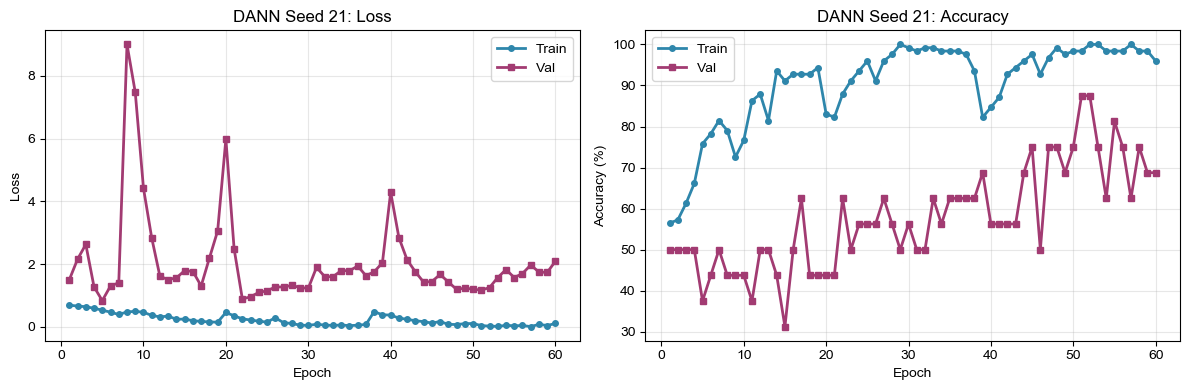

In [12]:
seed, metrics, history = train_dann(
    seed=21,
    source_train_loader=source_train_loader,
    target_train_loader=target_train_loader,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC
)

all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_class_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'DANN Seed {seed}'
)


Evaluating Best Model (Seed 21)


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=14.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 8.001666666666665
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 7.0016

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8571       93.75%       75.00%    0.6112
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    1.5728
-------------------------------------------------------------------------------------


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Devanagari Sangam MN.ttc', name='Devanagari Sangam MN', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Impact.ttf', name='Impact', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/11640094b5edf37d3e1ba1ef7794a5605a0491aa.asset/AssetData/LavaTelugu.ttc', name='Lava Telugu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Savoye LET.ttc', name='Savoye LET', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplo

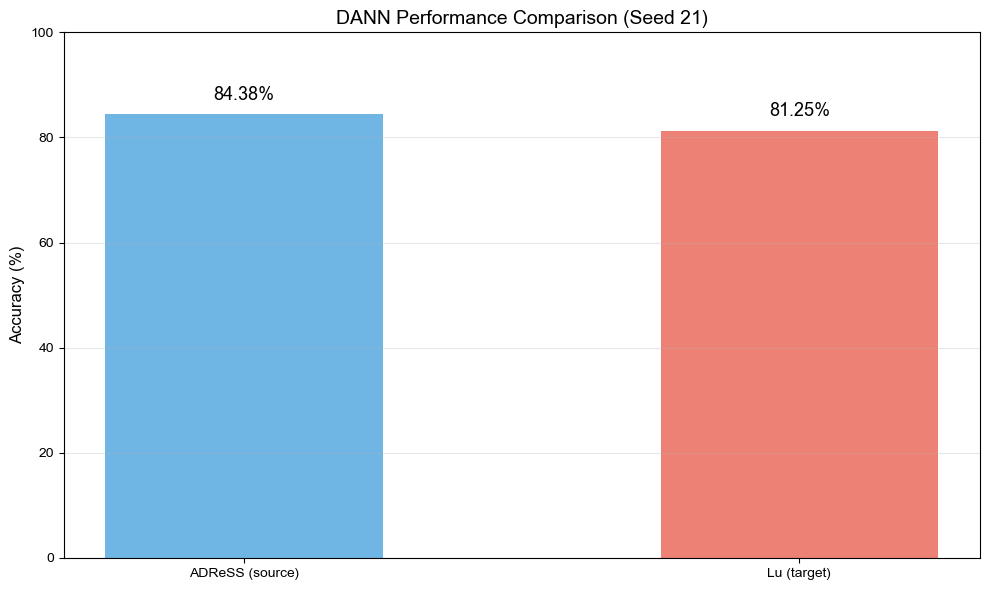

In [13]:
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann_finetuned_xlsr.pth"
source_metrics, target_metrics = evaluate_and_visualize(
    seed, source_val_loader, target_val_loader, model_path, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 42

In [ ]:
seed, metrics, history = train_dann(42, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann_finetuned_xlsr.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


Training Seed 42
XLSR Features: FINETUNED (extracted using finetuned_xlsr.pth, frozen)
Model Selection: Average Accuracy (Source 0.700, Target 0.300)
Accuracy Thresholds: Source >= 0.75, Target >= 0.70


Epoch 1:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   1 | Train: 0.524 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch 2:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   2 | Train: 0.548 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


...

Epoch 21:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  21 | Train: 0.976 | Source Val: 0.625 | Target Val: 0.750 | Avg: 0.662 | Domain: 0.504 | λ_dom: 0.007


Epoch 22:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  22 | Train: 0.960 | Source Val: 0.656 | Target Val: 0.750 | Avg: 0.684 | Domain: 0.517 | λ_dom: 0.013


Epoch 23:   0%|          | 0/4 [00:00<?, ?it/s]

### Seed 84

In [ ]:
seed, metrics, history = train_dann(84, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann_finetuned_xlsr.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 168

In [ ]:
seed, metrics, history = train_dann(168, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann_finetuned_xlsr.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 336

In [ ]:
seed, metrics, history = train_dann(336, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann_finetuned_xlsr.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## 4 Summary and Visualization


In [ ]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (source domain)     76.88% ± 1.53%    0.7870 ± 0.0221      0.5196
Lu (target domain)         75.00% ± 0.00%    0.7778 ± 0.0000      1.4644
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (source domain)         78.12%      0.8000       87.50%       68.75%    0.4595
         Lu (target domain)             75.00%      0.7778       87.50%       62.50%    1.1928
------------------------------------------------------------------------------------------
42       ADReSS (source domain)         75.00%      0.7500       75.00%       75.00%    0.4539
         Lu (target do